In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
import pyFAI
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator;
import h5py
from scipy.ndimage import gaussian_filter

  File "/software/mamba/2024.01/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/software/mamba/2024.01/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/fperakis/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/fperakis/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/home/fperakis/.venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/fperakis/.venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/software/mamba/2024.01/lib/python3.11/asyncio/base_events.py", line 607, in run_forever
    self._run_once()
  File "/software/mamba/2024.01/lib/python3.11/asyncio/base_events.py", line 1922, in _run_once

In [2]:
def check_spot(Iq, thr1 = 0.1, thr2 = 0.1, thr3 = 0.1):
    """
    Filters the shot based on several criteria bsed on three thresholds:
    - thr1: intensity threshold for the copper peak 
    - thr2: intensity threshold for the "sample" peak
    - thr3: difference intensity threshold for the bragg peaks
    """

    #constants
    i1,i2 = 870, 910 # q-indexes close to the copper ring
    j1, j2 = 20, 500 # q-indexes close to the LDA peak
 
    #initialise
    cooper_spot = False
    amorphous_spot = False
    sample_spot = False
    
    I_max = max(Iq[i1:i2]) # max in the copper range
    I_max2 = max(Iq[j1:j2]) # max in the ice range

    # check if it does not hit the copper grid
    if I_max>thr1 and I_max>I_max2: 
        cooper_spot = True
    else:
        # check if it hits the sample 
        if I_max2>thr3: 
            sample_spot = True
                
            # check for Bragg peaks
            Iq_smooth = gaussian_filter(Iq, sigma =20)
            diff = max(Iq-Iq_smooth)
            if diff<thr3: 
                amorphous_spot = True                
    return amorphous_spot, cooper_spot, sample_spot


## load motor positions

In [3]:
# parameters
sample = 'NPL14B'
run = 119
n_spots = 960#99 

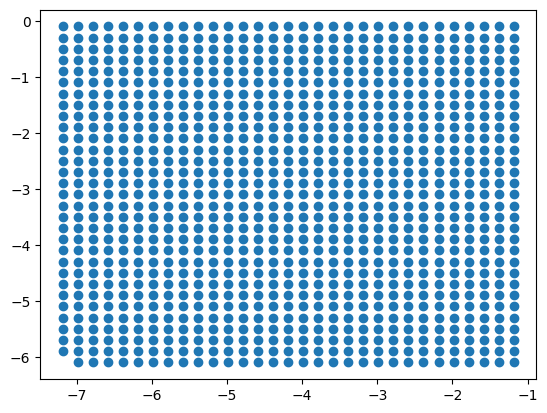

In [4]:
file_name = '%s_%05i'%(sample,run)
path_to_metadata = '/asap3/petra3/gpfs/p10/2026/data/11023455/raw/%s/%s.fio'%(file_name,file_name)
data = np.loadtxt(path_to_metadata, skiprows=126, max_rows=n_spots, usecols=range(9))
samy, samz = data[:,0],data[:,1]
plt.plot(samy, samz, 'o')
plt.show()

## Filter data

[y,z] = [-2.38, -5.50]
[y,z] = [-5.98, -5.30]
[y,z] = [-5.78, -5.30]
[y,z] = [-4.98, -5.30]
[y,z] = [-2.59, -5.30]
[y,z] = [-2.98, -4.90]
[y,z] = [-5.59, -4.70]
[y,z] = [-2.98, -4.70]
[y,z] = [-2.78, -4.70]
[y,z] = [-6.19, -4.50]
[y,z] = [-5.59, -4.50]
[y,z] = [-5.19, -4.50]
[y,z] = [-2.98, -4.50]
[y,z] = [-3.78, -4.10]
[y,z] = [-6.19, -3.70]
[y,z] = [-3.59, -3.70]
[y,z] = [-5.19, -3.50]
[y,z] = [-4.38, -3.50]
[y,z] = [-3.98, -3.50]
[y,z] = [-1.98, -3.50]
[y,z] = [-1.78, -3.50]
[y,z] = [-1.59, -3.50]
[y,z] = [-6.78, -3.30]
[y,z] = [-5.78, -3.30]
[y,z] = [-5.19, -3.30]
[y,z] = [-4.19, -3.30]
[y,z] = [-2.19, -3.10]
[y,z] = [-1.98, -3.10]
[y,z] = [-1.78, -3.10]
[y,z] = [-2.19, -2.90]
[y,z] = [-1.78, -2.90]
[y,z] = [-4.98, -2.70]
[y,z] = [-1.59, -2.70]
[y,z] = [-1.38, -2.70]
[y,z] = [-2.38, -2.30]
[y,z] = [-6.38, -2.10]
[y,z] = [-6.59, -1.90]
[y,z] = [-4.98, -1.30]
Found 38 good spots


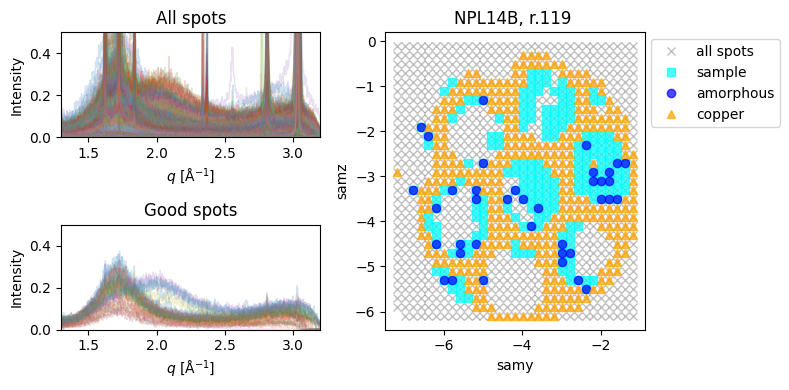

In [5]:
# parameters
q_bins=1000
det = 'e500'
i1, i2 = 20, 500 # indexes close to the LDA peak

# initialise
var = np.zeros(n_spots)
avg = np.zeros(n_spots)
good_spots = np.zeros(n_spots, dtype=bool)
copper_spots = np.zeros(n_spots, dtype=bool)
sample_spots = np.zeros(n_spots, dtype=bool)
n_spots = len(samy)

# load poni file
ai = pyFAI.load("/asap3/petra3/gpfs/p10/2026/data/11023455/shared/online_analysis/LaB6_2026-05-14.poni");

# file path
samplerun = f'{sample}_{"%05d" % run}'
path = f'/asap3/petra3/gpfs/p10/2026/data/11023455/raw/{samplerun}/{det}/{samplerun}_master.h5'
f = h5py.File(path)
data=np.array(f['entry']['data']['data_000001']) 

# load and plot
fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(2, 2)

# plot the I(q) of good spots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

for i in range(n_spots):
    q_waxs, Iq_waxs = ai.integrate1d(data[i], q_bins, mask = None, unit = 'q_A^-1') # This line does the integration.
    ax1.plot(q_waxs, Iq_waxs, lw=1, alpha=0.2)
    amorphous_spot, cooper_spot, sample_spot = check_spot(Iq_waxs)
    if amorphous_spot == True:
        ax2.plot(q_waxs, Iq_waxs, lw=1, alpha=0.2)
        good_spots[i]=True
        print("[y,z] = [%.2f, %.2f]"%(samy[i], samz[i]))
    if cooper_spot==True: copper_spots[i]=True
    if sample_spot==True: sample_spots[i]=True        
ax1.set_xlabel('$q$ [Å$^{-1}$]')
ax1.set_ylabel('Intensity')
ax2.set_xlabel('$q$ [Å$^{-1}$]')
ax2.set_ylabel('Intensity')
ax1.set_ylim(0,0.5)
ax1.set_xlim(1.3, 3.2)
ax1.set_title('All spots')
ax2.set_ylim(0,0.5)
ax2.set_xlim(1.3, 3.2)
ax2.set_title('Good spots')

n_good_spots = int(sum(good_spots))
print('Found %i good spots'%n_good_spots)

# plot 2d grid
ax3 = fig.add_subplot(gs[0:, 1:])
plt.plot(samy, samz, 'x', c='gray', alpha=0.5,label='all spots')
plt.plot(samy[sample_spots], samz[sample_spots], 's', c='cyan', alpha=0.7, label='sample')
plt.plot(samy[good_spots], samz[good_spots], 'o', c='blue', alpha=0.7, label = 'amorphous')
plt.plot(samy[copper_spots], samz[copper_spots], '^', c='orange', alpha=0.7, label='copper')

ax3.set_xlabel('samy')
ax3.set_ylabel('samz')
ax3.legend(bbox_to_anchor=(1.0, 1.0))
ax3.set(title=f"%s, r.%i "%(sample, run))
plt.tight_layout()

#plt.savefig(f"%s_mesh.png"%(sample), dpi=600)

plt.show()